In [28]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_files
from pyvi import ViTokenizer

from sklearn import svm
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve
%matplotlib inline


In [29]:
data_train = load_files(container_path="data/news_1135/", encoding="utf-8")
print(data_train.filenames)
print()
print("Tong so file: {}" .format( len(data_train.filenames)))
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )


['data/news_1135/Tin kh†c\\0218e1df21ce358b9c6485176a48f1fcaeedef67.txt'
 'data/news_1135/Khoa học - Công nghệ\\bf9889f5f2ffd6c92fa877d35ef0ef5f34f0666d.txt'
 'data/news_1135/Tin kh†c\\d74aab054ffe9f8661df13bc52b438b48a63fe48.txt'
 ...
 'data/news_1135/Thời sự\\a06c1ec4c146d3b4eb5070a1967e10e5e21bdc5b.txt'
 'data/news_1135/Sức khỏe\\4187c4a1d528fd9ea4630d2709229df0b0d09c3d.txt'
 'data/news_1135/Thể thao\\7adaf0c561796f2411340150f18417543ad4403c.txt']

Tong so file: 1135
Danh sách nhãn và id tương ứng:  [(0, 'Giải trí'), (1, 'Khoa học - Công nghệ'), (2, 'Kinh tế'), (3, 'Pháp luật'), (4, 'Sức khỏe'), (5, 'Thể thao'), (6, 'Thời sự'), (7, 'Tin kh†c'), (8, 'Độc giả'), (9, 'Đời sống - Xã hội')]


In [30]:
with open("data/vietnamese-stopwords.txt", encoding="utf-8") as f:
    stop_words = f.readlines()
stop_words = [word.strip().replace(" ","_") for word in stop_words]
print(stop_words[:10])

['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']


In [ ]:
module_count_vector = CountVectorizer(stop_words=stop_words)
model_rf_preprocess = Pipeline([("count_vector", module_count_vector),("tfidf", TfidfTransformer())])

data_preprocessed = model_rf_preprocess.fit_transform(data_train.data, data_train.target)
data_preprocessed.shape, data_train.target.shape


((1135, 24389), (1135,))

In [35]:
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((908, 24389), (908,), (227, 24389), (227,))

In [36]:
from sklearn.svm import SVC
model_svm = SVC(kernel="linear", random_state=42)
model_svm.fit(X_train, y_train)
print("Độ chính xác trên tập huấn luyện: {:.2f}%".format(model_svm.score(X_train, y_train)*100))
print("Độ chính xác trên tập kiểm tra: {:.2f}%".format(model_svm.score(X_test, y_test)*100))


Độ chính xác trên tập huấn luyện: 99.34%
Độ chính xác trên tập kiểm tra: 83.26%


In [37]:
model_svm2 = SVC(kernel="rbf", random_state=42)
model_svm2.fit(X_train, y_train)
print("Độ chính xác trên tập huấn luyện: {:.2f}%".format(model_svm2.score(X_train, y_train)*100))
print("Độ chính xác trên tập kiểm tra: {:.2f}%".format(model_svm2.score(X_test, y_test)*100))

Độ chính xác trên tập huấn luyện: 99.78%
Độ chính xác trên tập kiểm tra: 71.37%


In [40]:
# Tiền xử lý dữ liệu sử dụng module model_rf_preprocess.
new_doc = "Công phượng ghi bàn cho đội tuyển Việt nam"
# Trước hết, cần thực hiện tách từ sử dụng pyvi
tokenized_new_doc = ViTokenizer.tokenize(new_doc)
# Cần đưa văn bản ở dạng mảng/vector
tokenized_new_doc = [tokenized_new_doc]
print(tokenized_new_doc)
# Rồi sử dụng module model_rf_preprocess
input_data_preprocessed = model_rf_preprocess.transform(tokenized_new_doc)
print(input_data_preprocessed)
# Dự đoán nhãn của văn bản mới sử dụng model_svm
predicted_label = model_svm.predict(input_data_preprocessed)
print("Văn bản mới: ", new_doc)
predicted_label_rbf = model_svm2.predict(input_data_preprocessed)
print("Nhãn dự đoán (kernel linear): ", data_train.target_names[predicted_label[0]], "- Nhãn dự đoán (kernel rbf): ", data_train.target_names[predicted_label_rbf[0]])

['Công phượng ghi_bàn cho đội_tuyển Việt_nam']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (1, 24389)>
  Coords	Values
  (0, 5847)	0.33023750089838017
  (0, 7777)	0.4617859604824952
  (0, 15553)	0.6394232142292748
  (0, 21498)	0.23577234678310735
  (0, 24149)	0.4617859604824952
Văn bản mới:  Công phượng ghi bàn cho đội tuyển Việt nam
Nhãn dự đoán (kernel linear):  Thể thao - Nhãn dự đoán (kernel rbf):  Thể thao


In [41]:
params_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
'gamma': [0.0001, 0.001, 0.01, 0.1],
'kernel':['linear','rbf', 'poly'] }

grid_search = GridSearchCV(SVC(random_state=42), params_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation score: {:.2f}%".format(grid_search.best_score_ * 100))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters:  {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score: 85.02%


In [43]:
model_svm = SVC(C=grid_search.best_params_['C'], kernel=grid_search.best_params_['kernel'], gamma=grid_search.best_params_['gamma'], random_state=42)
model_svm.fit(X_train, y_train)
print("Độ chính xác trên tập huấn luyện: {:.2f}%".format(model_svm.score(X_train, y_train)*100))
print("Độ chính xác trên tập kiểm tra: {:.2f}%".format(model_svm.score(X_test, y_test)*100))

Độ chính xác trên tập huấn luyện: 99.89%
Độ chính xác trên tập kiểm tra: 83.26%


Dữ liệu training =  (1437, 64) (1437,)
Dữ liệu testing =  (360, 64) (360,)


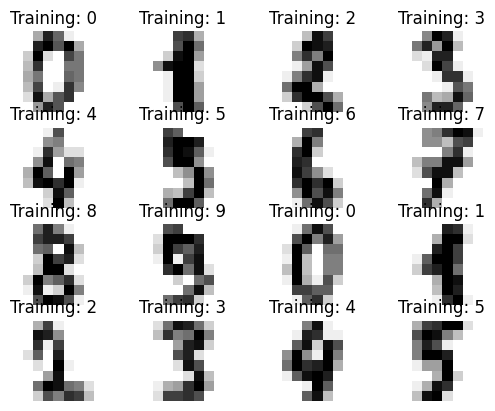

In [46]:
# The digits dataset
digits_loaded = datasets.load_digits()

# Handle both possible return types (Bunch or tuple) safely
if isinstance(digits_loaded, tuple):
    data_raw, target = digits_loaded
    images = data_raw.reshape((-1, 8, 8))
else:
    images = digits_loaded.images
    target = digits_loaded.target

# The data that we are interested in is made of 8x8 images of digits, let's
# have a look at the first 4 images, stored in the `images` attribute of the
# dataset. If we were working from image files, we could load them using
# matplotlib.pyplot.imread. Note that each image must have the same size. For these
# images, we know which digit they represent: it is given in the 'target' of
# the dataset.
images_and_labels = list(zip(images, target))
for index, (image, label) in enumerate(images_and_labels[:16]):
    plt.subplot(4, 4, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)

# To apply a classifier on this data, we need to flatten the image, to
# turn the data in a (samples, feature) matrix:
n_samples = len(images)
data = images.reshape((n_samples, -1))

test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=test_size, random_state=42)
print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)



In [47]:
model_svm = SVC(kernel="rbf", random_state=42)
model_svm.fit(X_train, y_train)

print("Độ chính xác trên tập huấn luyện: {:.2f}%".format(model_svm.score(X_train, y_train)*100))
print("Độ chính xác trên tập kiểm tra: {:.2f}%".format(model_svm.score(X_test, y_test)*100))

Độ chính xác trên tập huấn luyện: 99.65%
Độ chính xác trên tập kiểm tra: 98.61%


6


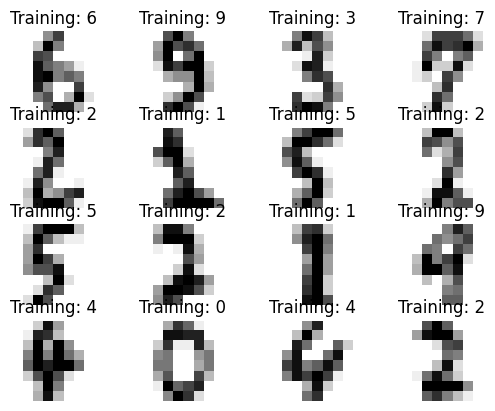

In [55]:
y_pred = model_svm.predict(X_test)
print(y_pred[0])

for index in range(16):
    
    image = X_test[index].reshape(8, 8)
    label = y_test[index]
    plt.subplot(4,4,index+1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('Training: %i' % label)
